In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

'''
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

"\nimport os\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n"

# Importing necessary libraries

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns


# Tiny dataset

In [2]:
# 1. Tiny dataset

# Small set of short sentences so the code stays simple and easy to inspect. 
sentences = [
    "i like deep learning",
    "transformers are powerful",
    "attention helps models focus",
    "we love natural language processing",
    "pytorch makes experiments easy",
    "this is a tiny transformer",
    "self attention mixes context",
    "positional encoding adds order",
    "words become embeddings",
    "encoder only models are useful"
]


# Tokenization

In [3]:
# 2. Tokenization

# Building a word-level vocabulary from all words in the dataset.
# Special tokens:
# - <pad>: used to pad shorter sentences to the same length
# - <unk>: used for unknown words, just in case
special_tokens = ["<pad>", "<unk>"]

word_set = set()
for s in sentences:
    word_set.update(s.lower().split())

# Final vocabulary = special tokens + sorted unique words
vocab = special_tokens + sorted(word_set)

# stoi = string-to-index, itos = index-to-string
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}

# Convert a sentence into a list of token IDs
def tokenize(sentence):
    return [stoi.get(w, stoi["<unk>"]) for w in sentence.lower().split()]

# Tokenize all sentences
tokenized = [tokenize(s) for s in sentences]

# Find longest sentence so we can pad all sequences to the same length
max_len = max(len(x) for x in tokenized)

# Pad a sequence with <pad> tokens up to max_len
def pad(seq, max_len):
    return seq + [stoi["<pad>"]] * (max_len - len(seq))

# Final input tensor:
# shape = [batch_size, sequence_length]
X = torch.tensor([pad(seq, max_len) for seq in tokenized])

print("Input tokens:")
for s, seq in zip(sentences, X):
    print(s)
    print([itos[i.item()] for i in seq])
    print()


Input tokens:
i like deep learning
['i', 'like', 'deep', 'learning', '<pad>']

transformers are powerful
['transformers', 'are', 'powerful', '<pad>', '<pad>']

attention helps models focus
['attention', 'helps', 'models', 'focus', '<pad>']

we love natural language processing
['we', 'love', 'natural', 'language', 'processing']

pytorch makes experiments easy
['pytorch', 'makes', 'experiments', 'easy', '<pad>']

this is a tiny transformer
['this', 'is', 'a', 'tiny', 'transformer']

self attention mixes context
['self', 'attention', 'mixes', 'context', '<pad>']

positional encoding adds order
['positional', 'encoding', 'adds', 'order', '<pad>']

words become embeddings
['words', 'become', 'embeddings', '<pad>', '<pad>']

encoder only models are useful
['encoder', 'only', 'models', 'are', 'useful']



# Positional Encoding

In [4]:
# 3. Positional Encoding

# Self-attention by itself does not know word order. Positional encoding injects position information into each token embedding.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()

        # pe will store a fixed sinusoidal encoding table:
        # shape = [max_len, d_model]
        pe = torch.zeros(max_len, d_model)

        # position = 0,1,2,...,max_len-1
        position = torch.arange(0, max_len).unsqueeze(1).float()

        # Even and odd dimensions use different sine/cosine frequencies
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # Apply sine to even dimensions and cosine to odd dimensions
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # register_buffer means:
        # "store this tensor with the model, but do not train it"
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        # x shape: [batch_size, seq_len, d_model]
        # Add the positional vectors to the token embeddings
        return x + self.pe[:, :x.size(1)]



# Multi-Head Self-Attention

In [5]:

# 4. Multi-Head Self-Attention

# This is the core Transformer operation. Each head learns to focus on different relationships between words.
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        # d_model must be divisible by number of heads
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_head = d_model // num_heads

        # Linear layers that produce Queries, Keys, and Values
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

        # Final linear layer after concatenating all heads
        self.Wo = nn.Linear(d_model, d_model)

    def forward(self, x):
        # x shape: [B, T, D]
        B, T, D = x.shape

        '''
        [B, T, d_model] is the standard tensor shape notation used in Transformer models:

        B = Batch size = Number of sentences you're processing at once. eg: B=10 means 10 sentences in a batch
        T = Time/Sequence length = Number of tokens (words) per sentence
        eg: i like deep learning → T=4 tokens
        d_model = Model dimension (Size of each token's embedding vector). eg: d_model=32 means each word becomes a 32-dimensional vector
        '''

        # Project the input embeddings into Q, K, V
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        # Split the model dimension into multiple heads:
        # [B, T, D] -> [B, T, num_heads, d_head] -> [B, num_heads, T, d_head]
        Q = Q.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.d_head).transpose(1, 2)

        # Compute scaled dot-product attention scores
        # scores shape: [B, num_heads, T, T]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)

        # Softmax converts scores into attention weights
        attn = torch.softmax(scores, dim=-1)

        # Weighted sum of values using attention weights
        out = torch.matmul(attn, V)

        # Concatenate all heads back together:
        # [B, num_heads, T, d_head] -> [B, T, D]
        out = out.transpose(1, 2).contiguous().view(B, T, D)

        # Final linear projection
        out = self.Wo(out)

        return out, attn



# Feed-Forward Network

In [7]:
# 5. Feed-Forward Network

# A small MLP applied independently to each token position.
# It adds extra nonlinearity and feature mixing.
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)



# Encoder Layer

In [8]:
# 6. Encoder Layer

# One Transformer encoder layer has:
# 1) Multi-head self-attention
# 2) Add & Norm
# 3) Feed-forward network
# 4) Add & Norm
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # Self-attention sublayer
        attn_out, attn_weights = self.attn(x)

        # Residual connection + layer norm
        # This helps gradient flow and stabilizes training
        x = self.norm1(x + attn_out)

        # Feed-forward sublayer
        ffn_out = self.ffn(x)

        # Second residual connection + layer norm
        x = self.norm2(x + ffn_out)

        return x, attn_weights



# Mini Transformer Encoder

In [9]:
# 7. Mini Transformer Encoder

# This is a small encoder-only Transformer
# embedding -> positional encoding -> encoder layer
class MiniTransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2, d_ff=64, max_len=20):
        super().__init__()

        # Learnable token embeddings
        self.embedding = nn.Embedding(vocab_size, d_model)

        # Fixed sinusoidal positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_len)

        # A single encoder layer
        self.encoder = EncoderLayer(d_model, num_heads, d_ff)

    def forward(self, x):
        # x shape: [B, T] where each value is a token ID
        x = self.embedding(x)      # -> [B, T, d_model]
        x = self.pos_encoding(x)    # Adding position information
        x, attn = self.encoder(x)   # Run through self-attention + FFN
        return x, attn



# Run the model

In [10]:
# 8. Run the model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MiniTransformerEncoder(
    vocab_size=len(vocab),
    d_model=32,
    num_heads=2,
    d_ff=64,
    max_len=max_len
).to(device)

# Move input batch to device
X = X.to(device)

# Forward pass only: no training here
with torch.no_grad():
    contextual_embeddings, attention = model(X)



# Final embeddings

In [11]:
# 9. Show final embeddings

# contextual_embeddings shape:
# [batch_size, sequence_length, d_model]
print("Final contextual embeddings shape:", contextual_embeddings.shape)

print("\nFinal contextual embeddings for first sentence:")
print(contextual_embeddings[0])



Final contextual embeddings shape: torch.Size([10, 5, 32])

Final contextual embeddings for first sentence:
tensor([[-1.0167, -1.2984, -1.7393,  0.6705, -0.4537, -0.5820, -0.9293, -0.1254,
          0.6023,  0.0057,  0.8813,  0.3754, -0.1656,  0.7837,  0.9905,  0.5625,
         -1.5312, -0.9555, -0.8736, -0.4724,  0.8696,  0.8177, -1.0552, -1.2665,
         -1.0525,  0.0232, -0.5274,  1.4302,  1.5747,  1.2313,  1.3452,  1.8811],
        [ 0.0411, -0.4030,  0.2361,  1.2463, -0.6152,  0.3492, -0.4984, -0.0384,
         -0.2002,  0.6814, -0.8365, -3.1879,  0.3550,  0.6800, -0.9943,  1.7152,
         -0.2009,  0.1936, -0.8416,  0.3825,  0.1121,  1.1871, -1.3900, -1.4785,
         -0.4530,  1.1474, -0.9789, -0.1725,  1.2957,  0.6689,  0.5055,  1.4921],
        [ 0.2957, -1.7941,  1.7456,  0.2454, -0.0754,  0.7984, -0.4063,  1.3253,
         -0.7384, -0.9268,  0.3244, -0.6396,  0.9676,  0.5935,  0.5900, -0.1850,
         -0.7627, -1.2533, -1.1776, -1.4997, -0.9400, -0.9989, -1.6256, -0.3616,

# ATTENTION HEATMAPS


=== Attention Heatmaps for ALL 2 HEADS ===
Sentence: 'i like deep learning'
Words: ['i', 'like', 'deep', 'learning']


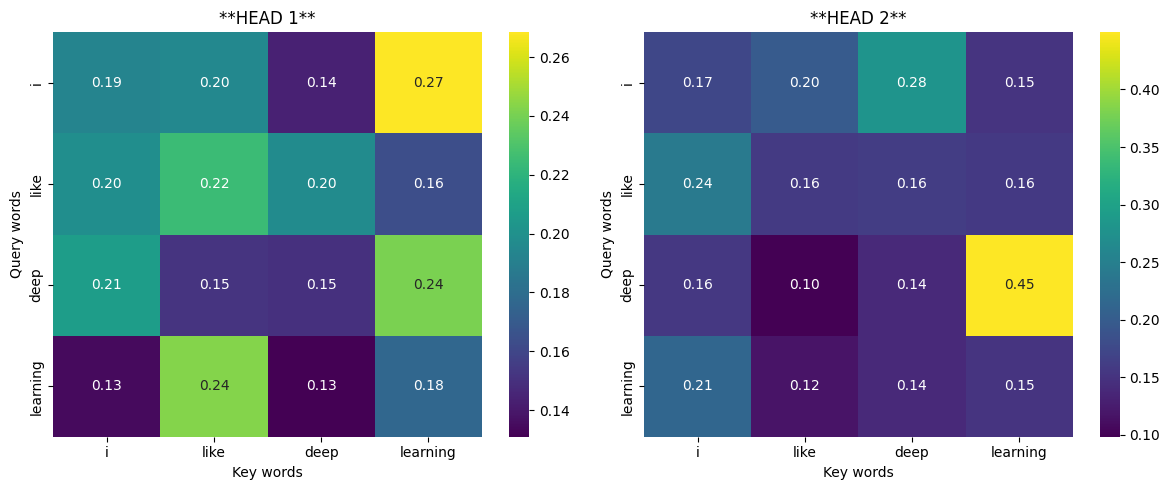


=== ATTENTION PATTERNS PER HEAD ===

Head 1:
  'i' → 'learning' (0.268)
  'like' → 'like' (0.225)
  'deep' → 'learning' (0.241)
  'learning' → 'like' (0.243)

Head 2:
  'i' → 'deep' (0.280)
  'like' → 'i' (0.241)
  'deep' → 'learning' (0.450)
  'learning' → 'i' (0.213)


In [12]:
# 10. DYNAMIC ATTENTION HEATMAPS - FOR ALL HEADS

sentence_idx = 0  # First sentence: "i like deep learning"
words = sentences[sentence_idx].lower().split()
num_heads = 2  # From model setup

# attention shape: [batch_size, num_heads, seq_len, seq_len]
print(f"\n=== Attention Heatmaps for ALL {num_heads} HEADS ===")
print(f"Sentence: '{sentences[sentence_idx]}'")
print(f"Words: {words}")

# Creating a grid of subplots: 1 row, num_heads columns
fig, axes = plt.subplots(1, num_heads, figsize=(6*num_heads, 5))
if num_heads == 1:
    axes = [axes]  # Make sure axes is always a list

for head_idx in range(num_heads):
    # Extracting attention matrix for this head, non-padding tokens only

    # attention shape:
    # [batch_size, num_heads, seq_len, seq_len]
    attn_matrix = attention[sentence_idx, head_idx].cpu().numpy()[:len(words), :len(words)]
    
    sns.heatmap(
        attn_matrix,
        xticklabels=words,
        yticklabels=words,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=axes[head_idx]
    )
    axes[head_idx].set_title(f"**HEAD {head_idx+1}**")
    axes[head_idx].set_xlabel("Key words")
    axes[head_idx].set_ylabel("Query words")

plt.tight_layout()
plt.show()


# 11. Printing attention patterns for each head

print("\n=== ATTENTION PATTERNS PER HEAD ===")
for head_idx in range(num_heads):
    attn_matrix = attention[sentence_idx, head_idx].cpu().numpy()[:len(words), :len(words)]
    
    print(f"\nHead {head_idx+1}:")
    for i, word_query in enumerate(words):
        max_attn_idx = attn_matrix[i].argmax()
        max_attn_word = words[max_attn_idx]
        max_attn_score = attn_matrix[i, max_attn_idx]
        print(f"  '{word_query}' → '{max_attn_word}' ({max_attn_score:.3f})")